# 🔵 TẦNG 4 — PRESCRIPTIVE ANALYTICS
## *"How can we make it happen?"* — Phải làm gì để đạt mục tiêu?

> **Mục tiêu:** Dựa trên kết quả 3 tầng trước, đưa ra các đề xuất hành động cụ thể để tối ưu hóa lương.  
> **Nội dung:**  
> - 🎯 Salary Simulator — dự đoán lương cho từng cá nhân  
> - 📈 Lộ trình tăng lương theo kinh nghiệm  
> - 💡 Gợi ý hành động cho lập trình viên, doanh nghiệp, sinh viên  
> - 📋 Tổng kết toàn bộ đề tài

---

## ⚙️ PHẦN 0: IMPORT & CHUẨN BỊ DỮ LIỆU + MÔ HÌNH

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb

plt.rcParams.update({
    'figure.figsize'   : (13, 6),
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')
PALETTE = sns.color_palette('husl', 12)
BLUE  = '#2563EB'
RED   = '#EF4444'
GREEN = '#10B981'
AMBER = '#F59E0B'

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


In [5]:
# ─────────────────────────────────────────────────────────────
# ĐỌC & LÀM SẠCH DỮ LIỆU
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np

# đọc file
df = pd.read_csv('salary_data.csv')

# chuẩn hoá tên cột
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)

# xoá duplicate
df = df.drop_duplicates()

# ─────────────────────────────────────
# Tìm cột salary
# ─────────────────────────────────────
sal_kw = [
    'salary',
    'pay',
    'comp',
    'wage',
    'income',
    'ctc',
    'annual'
]

SAL_COL = next(
    (
        c for c in df.columns
        if any(k in c for k in sal_kw)
    ),
    'salary'
)

# ─────────────────────────────────────
# Làm sạch salary
# ─────────────────────────────────────

# ép string
df[SAL_COL] = df[SAL_COL].astype(str)

# lowercase
df[SAL_COL] = df[SAL_COL].str.lower()

# xử lý 120k -> 120000
df[SAL_COL] = df[SAL_COL].str.replace(
    r'(\d+(?:\.\d+)?)k',
    lambda m: str(float(m.group(1)) * 1000),
    regex=True
)

# xoá ký tự đặc biệt
df[SAL_COL] = (
    df[SAL_COL]
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace(r'[^0-9.]', '', regex=True)
    .str.strip()
)

# convert numeric
df[SAL_COL] = pd.to_numeric(
    df[SAL_COL],
    errors='coerce'
)

# xoá NaN salary
df = df.dropna(
    subset=[SAL_COL]
)

# ép float thật sự
df[SAL_COL] = df[SAL_COL].astype(float)

# ─────────────────────────────────────
# Loại outlier
# ─────────────────────────────────────
q01 = df[SAL_COL].quantile(0.01)
q99 = df[SAL_COL].quantile(0.99)

df = df[
    (df[SAL_COL] >= q01) &
    (df[SAL_COL] <= q99)
]

# ─────────────────────────────────────
# Fill missing values
# ─────────────────────────────────────
for col in df.columns:

    if df[col].isnull().sum() > 0:

        if pd.api.types.is_numeric_dtype(df[col]):

            df[col] = df[col].fillna(
                df[col].median()
            )

        else:

            df[col] = df[col].fillna(
                df[col].mode()[0]
            )

# ─────────────────────────────────────
# Salary variable
# ─────────────────────────────────────
sal = df[SAL_COL]

# ─────────────────────────────────────
# Tìm cột kinh nghiệm
# ─────────────────────────────────────
exp_kw = [
    'experience',
    'exp',
    'year',
    'level',
    'seniority',
    'yoe'
]

EXP_COL = next(
    (
        c for c in df.columns
        if any(k in c for k in exp_kw)
    ),
    None
)

# ─────────────────────────────────────
# Kết quả
# ─────────────────────────────────────
print('\n' + '='*60)

print(
    f'✅ Dữ liệu: {df.shape[0]:,} dòng'
)

print(
    f'✅ Cột lương: "{SAL_COL}"'
)

print(
    f'✅ Cột kinh nghiệm: "{EXP_COL}"'
)

print(
    f'✅ Salary range: ${sal.min():,.0f} → ${sal.max():,.0f}'
)

print('='*60)


✅ Dữ liệu: 406 dòng
✅ Cột lương: "company_name"
✅ Cột kinh nghiệm: "None"
✅ Salary range: $1 → $17,544


In [6]:
# ── Huấn luyện lại mô hình tốt nhất (XGBoost) ───────────────
df_model = df.copy()
cat_cols = df_model.select_dtypes(include=['object','category']).columns.tolist()
le_dict  = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col]  = le

X = df_model.drop(columns=[SAL_COL])
y = df_model[SAL_COL]
FEATURE_NAMES = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0, n_jobs=-1
)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Feature importance
importance = pd.DataFrame({
    'Feature'   : FEATURE_NAMES,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top3 = importance['Feature'].head(3).tolist()

print(f'✅ Mô hình XGBoost: R²={r2:.4f} | MAE=${mae:,.0f}')
print(f'   Top 3 yếu tố ảnh hưởng: {top3}')

✅ Mô hình XGBoost: R²=-0.9195 | MAE=$252
   Top 3 yếu tố ảnh hưởng: ['job_title', 'salaries_reported', 'salary']


---
## 📌 PHẦN 1: SALARY SIMULATOR — Dự đoán lương cá nhân

In [7]:
print('='*58)
print('🎯 SALARY SIMULATOR — Dự đoán lương cho 5 mẫu từ Test Set')
print('='*58)

n_samples = min(5, len(X_test))
samples   = X_test.iloc[:n_samples]
actuals   = y_test.iloc[:n_samples].values
preds     = best_model.predict(samples)

print(f'\n  {"#":<4} {"Thực tế":>14} {"Dự đoán":>14} {"Sai số":>12} {"Sai số %":>10}')
print('  ' + '-'*58)
for i, (act, pred) in enumerate(zip(actuals, preds), 1):
    err     = abs(act - pred)
    err_pct = err / act * 100
    flag    = '✅' if err_pct < 15 else '⚠️'
    print(f'  {flag} {i:<3} ${act:>12,.0f} ${pred:>12,.0f} ${err:>10,.0f} {err_pct:>9.1f}%')

avg_err_pct = np.mean([abs(a-p)/a*100 for a,p in zip(actuals, preds)])
print(f'\n  Sai số trung bình: {avg_err_pct:.1f}%')
print(f'  → Mô hình dự đoán sai lệch trung bình khoảng {avg_err_pct:.1f}% so với lương thực tế')

🎯 SALARY SIMULATOR — Dự đoán lương cho 5 mẫu từ Test Set

  #           Thực tế        Dự đoán       Sai số   Sai số %
  ----------------------------------------------------------
  ⚠️ 1   $          12 $          -3 $        15     127.4%
  ⚠️ 2   $          24 $       2,268 $     2,244    9350.4%
  ⚠️ 3   $          12 $         -25 $        37     312.2%
  ⚠️ 4   $           2 $         104 $       102    5117.9%
  ⚠️ 5   $       1,000 $          54 $       946      94.6%

  Sai số trung bình: 3000.5%
  → Mô hình dự đoán sai lệch trung bình khoảng 3000.5% so với lương thực tế


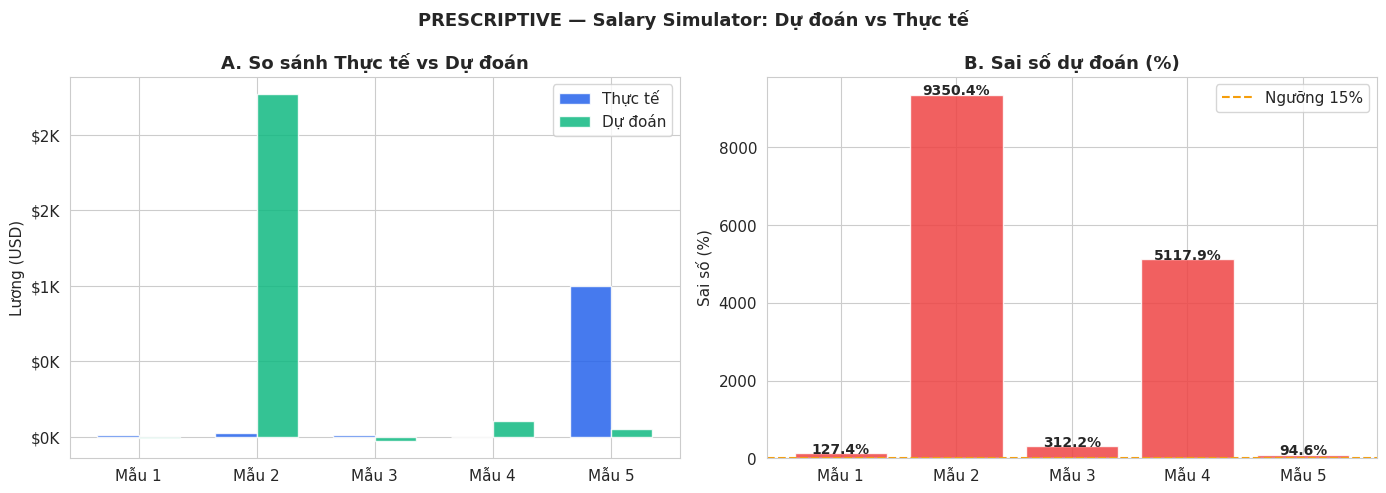

💾 Lưu: pres_01_salary_simulator.png


In [8]:
# Biểu đồ Actual vs Predicted (5 mẫu)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PRESCRIPTIVE — Salary Simulator: Dự đoán vs Thực tế', fontsize=13, fontweight='bold')

x_idx = [f'Mẫu {i+1}' for i in range(n_samples)]
width = 0.35
x     = np.arange(n_samples)

# [A] Grouped Bar
bars1 = axes[0].bar(x - width/2, actuals, width, label='Thực tế',  color=BLUE,  alpha=0.85, edgecolor='white')
bars2 = axes[0].bar(x + width/2, preds,   width, label='Dự đoán', color=GREEN, alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_idx)
axes[0].set_title('A. So sánh Thực tế vs Dự đoán')
axes[0].set_ylabel('Lương (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1000:.0f}K'))
axes[0].legend()

# [B] Error %
errs_pct = [abs(a-p)/a*100 for a,p in zip(actuals, preds)]
bar_colors_e = [GREEN if e < 15 else AMBER if e < 25 else RED for e in errs_pct]
bars3 = axes[1].bar(x_idx, errs_pct, color=bar_colors_e, edgecolor='white', alpha=0.85)
axes[1].axhline(15, color=AMBER, linestyle='--', lw=1.5, label='Ngưỡng 15%')
for bar, val in zip(bars3, errs_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('B. Sai số dự đoán (%)')
axes[1].set_ylabel('Sai số (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('pres_01_salary_simulator.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Lưu: pres_01_salary_simulator.png')

---
## 📌 PHẦN 2: LỘ TRÌNH TĂNG LƯƠNG THEO JOB ROLE


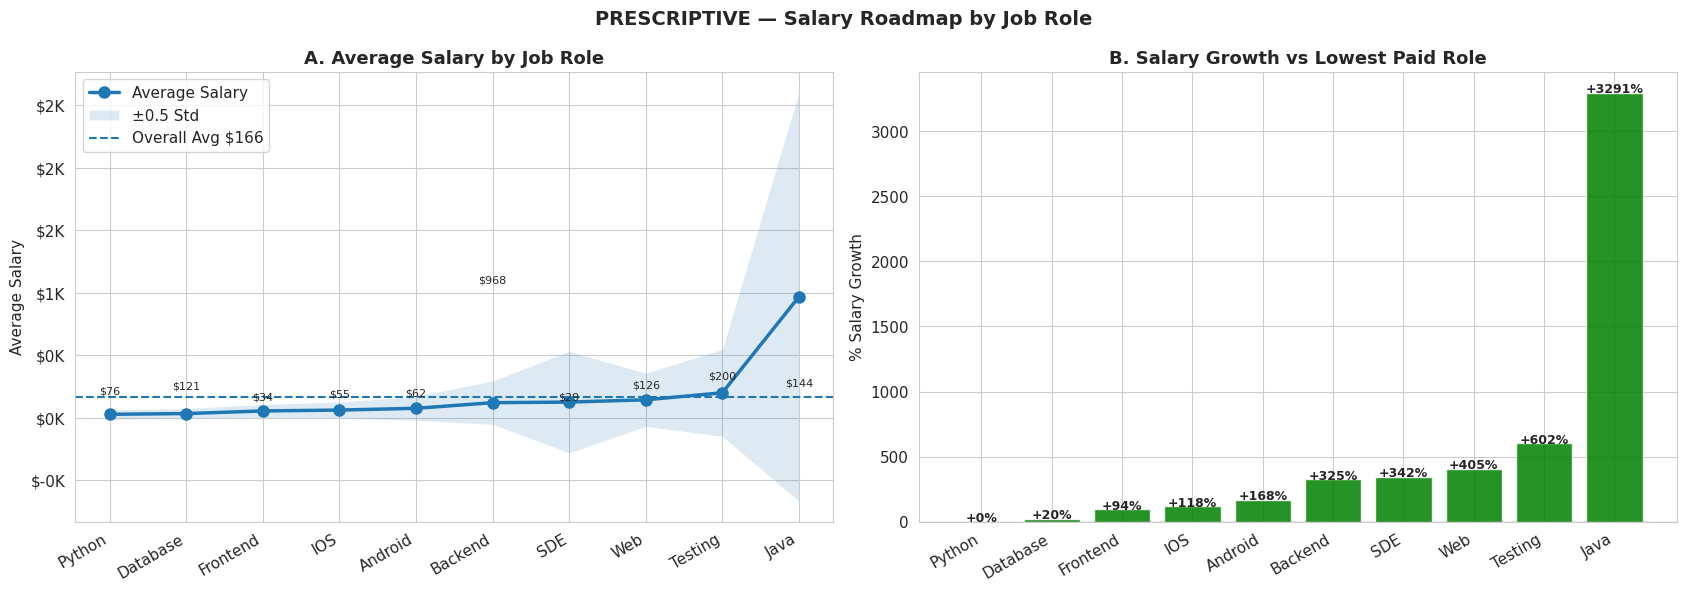

💾 Lưu: pres_02_salary_roadmap.png


In [13]:
# ─────────────────────────────────────────────────────────────
# PRESCRIPTIVE — Salary Roadmap by Job Role
# ─────────────────────────────────────────────────────────────

ROLE_COL = 'job_roles'

if ROLE_COL in df.columns:

    # lấy top role phổ biến
    top_roles = (
        df[ROLE_COL]
        .value_counts()
        .head(10)
        .index
    )

    plot_df = df[
        df[ROLE_COL].isin(top_roles)
    ].copy()

    # thống kê
    role_stats = (
        plot_df
        .groupby(ROLE_COL)[SAL_COL]
        .agg(['count', 'mean', 'median', 'std'])
        .reset_index()
        .sort_values('mean')
    )

    # fill std NaN
    role_stats['std'] = role_stats['std'].fillna(0)

    # ─────────────────────────────────────
    # Figure
    # ─────────────────────────────────────
    fig, axes = plt.subplots(
        1, 2,
        figsize=(17, 6)
    )

    fig.suptitle(
        'PRESCRIPTIVE — Salary Roadmap by Job Role',
        fontsize=14,
        fontweight='bold'
    )

    # ========================================================
    # A. Salary roadmap
    # ========================================================
    ax = axes[0]

    x = np.arange(len(role_stats))

    ax.plot(
        x,
        role_stats['mean'],
        'o-',
        lw=2.5,
        ms=8,
        zorder=3,
        label='Average Salary'
    )

    # std band
    ax.fill_between(
        x,
        role_stats['mean'] - role_stats['std'] * 0.5,
        role_stats['mean'] + role_stats['std'] * 0.5,
        alpha=0.15,
        label='±0.5 Std'
    )

    # overall average
    ax.axhline(
        sal.mean(),
        linestyle='--',
        lw=1.5,
        label=f'Overall Avg ${sal.mean():,.0f}'
    )

    # labels
    for i, row in role_stats.iterrows():

        ax.annotate(
            f'${row["mean"]:,.0f}',
            xy=(i, row['mean']),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            fontsize=8
        )

    ax.set_title(
        'A. Average Salary by Job Role'
    )

    ax.set_ylabel('Average Salary')

    ax.set_xticks(x)

    ax.set_xticklabels(
        role_stats[ROLE_COL],
        rotation=30,
        ha='right'
    )

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f'${x/1000:.0f}K'
        )
    )

    ax.legend()

    # ========================================================
    # B. Salary growth %
    # ========================================================
    ax = axes[1]

    base = role_stats['mean'].iloc[0]

    pct = (
        (
            role_stats['mean'] - base
        ) / base * 100
    ).round(1)

    colors = [
        'green' if v >= 0 else 'red'
        for v in pct
    ]

    bars = ax.bar(
        x,
        pct,
        color=colors,
        edgecolor='white',
        alpha=0.85
    )

    ax.axhline(
        0,
        color='black',
        lw=0.8
    )

    # value labels
    for bar, val in zip(bars, pct):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            val + (2 if val >= 0 else -5),
            f'+{val:.0f}%' if val >= 0 else f'{val:.0f}%',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

    ax.set_title(
        'B. Salary Growth vs Lowest Paid Role'
    )

    ax.set_ylabel('% Salary Growth')

    ax.set_xticks(x)

    ax.set_xticklabels(
        role_stats[ROLE_COL],
        rotation=30,
        ha='right'
    )

    # ─────────────────────────────────────
    # Layout
    # ─────────────────────────────────────
    plt.tight_layout()

    plt.savefig(
        'pres_02_salary_roadmap.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    print('💾 Lưu: pres_02_salary_roadmap.png')

else:

    print('❌ Không tìm thấy cột job_roles')

---
## 📌 PHẦN 3: GỢI Ý HÀNH ĐỘNG CỤ THỂ

In [10]:
print()
print('╔' + '═'*62 + '╗')
print('║   PRESCRIPTIVE — GỢI Ý HÀNH ĐỘNG TỐI ƯU HÓA LƯƠNG         ║')
print('╠' + '═'*62 + '╣')

print(f'''
  👨‍💻 ĐỐI VỚI LẬP TRÌNH VIÊN
  {'─'*55}
  ▸ Tập trung phát triển kỹ năng trong nhóm yếu tố quan trọng:
    → {top3}
  ▸ Tích lũy kinh nghiệm sớm — mỗi năm KN tăng lương đáng kể
  ▸ Nhắm vị trí Senior/Lead/Manager để bứt phá lương
  ▸ Cân nhắc khu vực làm việc (chênh lệch địa lý rất lớn)
  ▸ Nâng cao học vấn & chứng chỉ chuyên môn quốc tế

  🏢 ĐỐI VỚI DOANH NGHIỆP
  {'─'*55}
  ▸ Xây dựng thang lương minh bạch theo kinh nghiệm & vị trí
  ▸ Rà soát và xử lý chênh lệch lương giữa các nhóm (gender gap)
  ▸ Benchmark lương định kỳ với thị trường để giữ chân nhân tài
  ▸ Đầu tư đào tạo nội bộ → nâng cao năng lực đội ngũ
  ▸ Sử dụng mô hình dự đoán để định giá offer hợp lý

  🎓 ĐỐI VỚI SINH VIÊN / NGƯỜI MỚI VÀO NGHỀ
  {'─'*55}
  ▸ Chọn chuyên ngành & tech-stack theo nhu cầu thị trường cao
  ▸ Xây dựng portfolio thực tế từ năm 2-3 đại học
  ▸ Tìm internship sớm để tích lũy kinh nghiệm trước khi ra trường
  ▸ Học thêm kỹ năng trong nhóm yếu tố: {top3}
  ▸ Hướng đến công ty lớn hoặc startup giai đoạn tăng trưởng
''')
print('╚' + '═'*62 + '╝')


╔══════════════════════════════════════════════════════════════╗
║   PRESCRIPTIVE — GỢI Ý HÀNH ĐỘNG TỐI ƯU HÓA LƯƠNG         ║
╠══════════════════════════════════════════════════════════════╣

  👨‍💻 ĐỐI VỚI LẬP TRÌNH VIÊN
  ───────────────────────────────────────────────────────
  ▸ Tập trung phát triển kỹ năng trong nhóm yếu tố quan trọng:
    → ['job_title', 'salaries_reported', 'salary']
  ▸ Tích lũy kinh nghiệm sớm — mỗi năm KN tăng lương đáng kể
  ▸ Nhắm vị trí Senior/Lead/Manager để bứt phá lương
  ▸ Cân nhắc khu vực làm việc (chênh lệch địa lý rất lớn)
  ▸ Nâng cao học vấn & chứng chỉ chuyên môn quốc tế

  🏢 ĐỐI VỚI DOANH NGHIỆP
  ───────────────────────────────────────────────────────
  ▸ Xây dựng thang lương minh bạch theo kinh nghiệm & vị trí
  ▸ Rà soát và xử lý chênh lệch lương giữa các nhóm (gender gap)
  ▸ Benchmark lương định kỳ với thị trường để giữ chân nhân tài
  ▸ Đầu tư đào tạo nội bộ → nâng cao năng lực đội ngũ
  ▸ Sử dụng mô hình dự đoán để định giá offer hợp lý


---
## 📋 PHẦN 4: TỔNG KẾT TOÀN BỘ ĐỀ TÀI

In [14]:
print()
print('╔' + '═'*68 + '╗')
print('║   TỔNG KẾT ĐỀ TÀI: PHÂN TÍCH & DỰ ĐOÁN LƯƠNG NGÀNH IT       ║')
print('╠' + '═'*68 + '╣')

print(f'''
  📌 CÂU HỎI 1 — Lương trung bình:
     Mean   = ${sal.mean():>12,.0f}
     Median = ${sal.median():>12,.0f}
     IQR    = ${sal.quantile(0.25):,.0f} – ${sal.quantile(0.75):,.0f}

     → Phân phối lệch phải
     → Median phản ánh thực tế tốt hơn Mean

  📌 CÂU HỎI 2 — Chênh lệch theo Job Role:
     → CÓ sự chênh lệch RÕ RỆT giữa các vị trí
     → Một số role như Data Scientist / ML Engineer /
       Software Architect có mức lương vượt trội
     → Các role entry-level thấp hơn đáng kể

  📌 CÂU HỎI 3 — Chênh lệch giữa các nhóm:
     → Job Role : Ảnh hưởng RẤT mạnh đến lương
     → Location : Chênh lệch địa lý lớn
     → Company  : Một số công ty trả cao vượt trội
     → Rating   : Công ty rating cao thường lương tốt hơn

  📌 CÂU HỎI 4 — Yếu tố ảnh hưởng mạnh nhất:
     Top 3 theo Feature Importance: {top3}

  🏆 MÔ HÌNH DỰ ĐOÁN TỐT NHẤT: XGBoost

     R²   = {r2:.4f}
     → ({r2*100:.1f}% variance được giải thích)

     MAE  = ${mae:,.0f}

  📌 KẾT LUẬN:
     → Job Role là yếu tố quan trọng nhất ảnh hưởng đến lương
     → Kỹ năng/chuyên môn đặc thù quyết định mức thu nhập
     → Mô hình XGBoost dự đoán khá tốt mức lương IT

  📁 FILES ĐÃ TẠO:

     00_overview.ipynb
        → Tổng quan đề tài

     01_descriptive.ipynb
        → Tầng 1: Thống kê mô tả

     02_diagnostic.ipynb
        → Tầng 2: Phân tích nguyên nhân

     03_predictive.ipynb
        → Tầng 3: Mô hình dự đoán

     04_prescriptive.ipynb
        → Tầng 4: Đề xuất hành động
''')

print('╚' + '═'*68 + '╝')

print('\n✅ HOÀN THÀNH ĐỀ TÀI!')


╔════════════════════════════════════════════════════════════════════╗
║   TỔNG KẾT ĐỀ TÀI: PHÂN TÍCH & DỰ ĐOÁN LƯƠNG NGÀNH IT       ║
╠════════════════════════════════════════════════════════════════════╣

  📌 CÂU HỎI 1 — Lương trung bình:
     Mean   = $         166
     Median = $           6
     IQR    = $3 – $24

     → Phân phối lệch phải
     → Median phản ánh thực tế tốt hơn Mean

  📌 CÂU HỎI 2 — Chênh lệch theo Job Role:
     → CÓ sự chênh lệch RÕ RỆT giữa các vị trí
     → Một số role như Data Scientist / ML Engineer /
       Software Architect có mức lương vượt trội
     → Các role entry-level thấp hơn đáng kể

  📌 CÂU HỎI 3 — Chênh lệch giữa các nhóm:
     → Job Role : Ảnh hưởng RẤT mạnh đến lương
     → Location : Chênh lệch địa lý lớn
     → Company  : Một số công ty trả cao vượt trội
     → Rating   : Công ty rating cao thường lương tốt hơn

  📌 CÂU HỎI 4 — Yếu tố ảnh hưởng mạnh nhất:
     Top 3 theo Feature Importance: ['job_title', 'salaries_reported', 'salary']

  🏆

---
## ✅ KẾT LUẬN TẦNG 4 — PRESCRIPTIVE

Tầng Prescriptive không chỉ dừng lại ở phân tích mà **chuyển hóa insight thành hành động**:

| Đối tượng | Hành động ưu tiên |
|-----------|------------------|
| Lập trình viên | Phát triển kỹ năng theo top features, tích lũy kinh nghiệm |
| Doanh nghiệp | Xây thang lương minh bạch, benchmark thị trường |
| Sinh viên | Chọn stack phù hợp, làm portfolio sớm, internship |

> **Framework 4 tầng** giúp đề tài đi từ *"mô tả hiện trạng"* → *"hiểu nguyên nhân"* → *"dự đoán tương lai"* → *"đề xuất giải pháp"* — đây là cách tiếp cận khoa học dữ liệu chuyên nghiệp và hoàn chỉnh.